# Step 2 — BLIP-2 Captioning on GT-Cropped Images

**Visual Product Search Engine | DeepFashion In-Shop Retrieval**

This notebook:
1. Runs **BLIP-2** on every GT-cropped image to generate a product caption.
2. Compares BLIP-2 captions against the **ground-truth descriptions** from `list_description_inshop.json` using BERTScore.
3. Saves captions as a **`captions.json`** keyed by `rel_path` — exactly what Step 3 (CLIP fine-tuning) needs.

---
### Inputs
```
/kaggle/input/.../cropped_dataset/          ← GT-cropped images from Step 1
/kaggle/input/.../list_description_inshop.json  ← GT item descriptions
```
### Outputs
```
/kaggle/working/
    captions.json        ← {rel_path: caption} for every image
    blip2_vs_gt.json     ← BERTScore comparison results
    blip2_eval_sample.png
```

### `captions.json` format (what Step 3 reads)
```json
{
  "WOMEN/Dresses/id_00000002/02_1_front.jpg": "a black floral babydoll dress with short sleeves and round neckline",
  "WOMEN/Dresses/id_00000002/02_2_side.jpg" : "a black floral dress with short sleeves shown from the side",
  ...
}
```

## 0. Install dependencies

In [1]:
!pip install transformers accelerate bitsandbytes bert-score --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00


## 1. Imports & paths

In [2]:
import json
import random
from pathlib import Path

import torch
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Input paths ───────────────────────────────────────────────────────
# Cropped dataset from Step 1 (upload as a Kaggle dataset)
CROP_ROOT   = Path('/kaggle/input/datasets/sasank93/cropped-images-vr-final-project/cropped_img')
# GT descriptions JSON
DESC_FILE   = Path('/kaggle/input/datasets/sasank93/ground-truth-image-desc/list_description_inshop.json')

# ── Output paths ──────────────────────────────────────────────────────
WORK_DIR        = Path('/kaggle/working')
CAPTIONS_OUT    = WORK_DIR / 'captions.json'       # used by Step 3
EVAL_OUT        = WORK_DIR / 'blip2_vs_gt.json'    # BERTScore results

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
random.seed(SEED)

print(f'Device          : {DEVICE}')
print(f'Crop root exists: {CROP_ROOT.exists()} | {CROP_ROOT}')
print(f'Desc file exists: {DESC_FILE.exists()} | {DESC_FILE}')

# Count available crops
all_crops = sorted(CROP_ROOT.rglob('*.jpg'))
print(f'Total crop files: {len(all_crops):,}')

Device          : cuda
Crop root exists: True | /kaggle/input/datasets/sasank93/cropped-images-vr-final-project/cropped_img
Desc file exists: True | /kaggle/input/datasets/sasank93/ground-truth-image-desc/list_description_inshop.json
Total crop files: 49,788


## 2. Load GT descriptions

The JSON is keyed by `item_id`. We build a clean single-string description per item
by joining the first two lines (style description + fabric) — these are the most
visually relevant parts for comparison with BLIP-2 output.

In [3]:
with open(DESC_FILE, 'r') as f:
    raw_descriptions = json.load(f)

# Build dict: item_id → clean GT caption string
gt_captions = {}
for entry in raw_descriptions:
    item_id = entry['item']          # e.g. 'id_00000002'
    color   = entry.get('color', '')
    # Take first description line (style) + color — most visually relevant
    style_desc = entry['description'][0].strip() if entry['description'] else ''
    gt_captions[item_id] = f"{color}. {style_desc}".strip('. ')

print(f'GT descriptions loaded: {len(gt_captions):,} items')
print()
# Show a sample
for k, v in list(gt_captions.items())[:3]:
    print(f'{k}: {v[:120]}...')
    print()

GT descriptions loaded: 7,982 items

id_00000001: Cream. This sheer Georgette top features a high collar and shirred shoulders. Complete with long sleeves and buttoned cu...

id_00000002: Black-blush. Style Deals - When temps start to rise, slip into this supremely cute babydoll dress outfitted with a vibra...

id_00000003: Heather grey. F21 Contemporary - Structured separates that reference classic prep is our favorite way to create a refine...



## 3. Load BLIP-2



In [4]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig

MODEL_ID = 'Salesforce/blip2-flan-t5-xl'

# 8-bit config — separate object now in newer transformers
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

print(f'Loading BLIP-2 ({MODEL_ID}) in 8-bit...')
processor = Blip2Processor.from_pretrained(MODEL_ID)
model     = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,   # ← replaces load_in_8bit=True
    device_map='auto',
    torch_dtype=torch.float16,
)
model.eval()
print('BLIP-2 loaded.')

Loading BLIP-2 (Salesforce/blip2-flan-t5-xl) in 8-bit...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


BLIP-2 loaded.


## 4. Caption generation function

We use a **fashion-specific prompt** to guide BLIP-2 to describe the garment
rather than the person or background. This significantly improves caption quality
for downstream CLIP alignment.

In [5]:
PROMPT = PROMPT = (
    "Question: Describe this clothing item by completing each field:\n"
    "Color: \nStyle: \nFit: \nMaterial: \nDetails: \n"
    "Answer:"
)

def clean_caption(raw: str) -> str:
    """
    Convert structured BLIP-2 output into a clean sentence for CLIP.
    
    Input:  'Color: black Style: babydoll dress Fit: loose Material: rayon Details: floral print'
    Output: 'black babydoll dress, loose fit, rayon, floral print'
    """
    import re

    # If model filled fields properly, extract values and join
    fields = {}
    for field in ['Color', 'Style', 'Fit', 'Material', 'Details']:
        pattern = rf'{field}:\s*([^:]+?)(?=\s*(?:Color|Style|Fit|Material|Details):|$)'
        match = re.search(pattern, raw, re.IGNORECASE)
        if match:
            val = match.group(1).strip().rstrip(',')
            if val:
                fields[field] = val

    if len(fields) >= 3:
        # Structured output — build clean sentence
        parts = []
        if 'Color' in fields:
            parts.append(fields['Color'])
        if 'Style' in fields:
            parts.append(fields['Style'])
        if 'Fit' in fields:
            parts.append(f"{fields['Fit']} fit")
        if 'Material' in fields:
            parts.append(fields['Material'])
        if 'Details' in fields:
            parts.append(fields['Details'])
        return ', '.join(parts)
    else:
        # Model gave free-form output — return as-is
        return raw.strip()

def generate_captions_batch(image_paths: list[Path], batch_size: int = 16) -> list[str]:
    """
    Generate captions for a list of image paths in batches.
    Returns a list of caption strings in the same order.
    """
    captions = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        images = []
        for p in batch_paths:
            try:
                images.append(Image.open(p).convert('RGB'))
            except Exception:
                images.append(Image.new('RGB', (224, 224), (128, 128, 128)))  # grey placeholder

        inputs = processor(
            images=images,
            text=[PROMPT] * len(images),
            return_tensors='pt',
            padding=True,
        ).to(DEVICE, torch.float16)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=100,    # enough for a good caption, not too long
                num_beams=3,          # beam search for better quality
                repetition_penalty=1.2,
            )

        batch_captions = processor.batch_decode(generated_ids, skip_special_tokens=True)
        batch_captions = [clean_caption(c.replace(PROMPT, '').strip()) for c in batch_captions]
        captions.extend(batch_captions)

    return captions

# Quick test on 2 images
test_imgs = all_crops[:2]
test_caps = generate_captions_batch(test_imgs, batch_size=2)
for p, c in zip(test_imgs, test_caps):
    print(f'Image : {p.relative_to(CROP_ROOT)}')
    print(f'Caption: {c}')
    print()

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image : MEN/Denim/id_00000080/01_1_front.jpg
Caption: Color: Black

Image : MEN/Denim/id_00000080/01_2_side.jpg
Caption: a black pair of skinny jeans and white sneakers



## 5. Run BLIP-2 on all cropped images

Saves intermediate progress every 5000 images so you don't lose work if the session dies.

In [6]:
BATCH_SIZE    = 16     # fits T4 comfortably with opt-2.7b in 8-bit
SAVE_EVERY    = 5000   # checkpoint frequency

# Resume from checkpoint if it exists
CHECKPOINT = WORK_DIR / 'captions_checkpoint.json'
if CHECKPOINT.exists():
    with open(CHECKPOINT) as f:
        captions_dict = json.load(f)
    print(f'Resumed from checkpoint: {len(captions_dict):,} captions already done')
else:
    captions_dict = {}

# Filter to images not yet captioned
done_keys   = set(captions_dict.keys())
pending     = [p for p in all_crops
               if str(p.relative_to(CROP_ROOT)) not in done_keys]

print(f'Total images  : {len(all_crops):,}')
print(f'Already done  : {len(done_keys):,}')
print(f'To process    : {len(pending):,}')

# ── Main captioning loop ──────────────────────────────────────────────
pbar = tqdm(total=len(pending), desc='Generating captions')

for i in range(0, len(pending), BATCH_SIZE):
    batch_paths = pending[i : i + BATCH_SIZE]
    batch_caps  = generate_captions_batch(batch_paths, batch_size=BATCH_SIZE)

    for path, cap in zip(batch_paths, batch_caps):
        # Key = path relative to CROP_ROOT
        # e.g. 'WOMEN/Dresses/id_00000002/02_1_front.jpg'
        rel = str(path.relative_to(CROP_ROOT))
        captions_dict[rel] = cap

    pbar.update(len(batch_paths))

    # Save checkpoint every SAVE_EVERY images
    if (i // BATCH_SIZE) % (SAVE_EVERY // BATCH_SIZE) == 0 and i > 0:
        with open(CHECKPOINT, 'w') as f:
            json.dump(captions_dict, f, indent=2)
        pbar.set_postfix({'saved': len(captions_dict)})

pbar.close()

# Save final captions.json
with open(CAPTIONS_OUT, 'w') as f:
    json.dump(captions_dict, f, indent=2)

print(f'\nDone. {len(captions_dict):,} captions saved → {CAPTIONS_OUT}')

Total images  : 49,788
Already done  : 0
To process    : 49,788



Generating captions:   0%|          | 0/49788 [00:00<?, ?it/s]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Generating captions:   0%|          | 16/49788 [00:04<4:04:05,  3.40it/s]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Generating captions:   0%|  


Done. 49,788 captions saved → /kaggle/working/captions.json


## 6. BERTScore: Compare BLIP-2 vs GT descriptions

For each item that has a GT description, we compare the BLIP-2 caption of its
`02_1_front.jpg` (front view) against the GT text using **BERTScore**.

BERTScore measures semantic similarity using BERT embeddings — much better than
BLEU/ROUGE for open-ended text comparison.

- **F1 > 0.85** → excellent semantic alignment  
- **F1 ~ 0.80** → good, captions capture the main attributes  
- **F1 < 0.75** → captions are drifting from the product details

In [7]:
from bert_score import score as bert_score

# Match BLIP-2 captions to GT descriptions via item_id
# Use the front-view image as the representative caption per item
blip_texts = []
gt_texts   = []
matched_items = []

for rel_path, caption in captions_dict.items():
    # rel_path = 'WOMEN/Dresses/id_00000002/02_1_front.jpg'
    parts   = Path(rel_path).parts
    if len(parts) < 4:
        continue
    item_id  = parts[2]          # 'id_00000002'
    filename = parts[3]          # '02_1_front.jpg'

    # Only use front-view images for fair per-item comparison
    if 'front' not in filename:
        continue
    if item_id not in gt_captions:
        continue

    blip_texts.append(caption)
    gt_texts.append(gt_captions[item_id])
    matched_items.append(item_id)

print(f'Matched items for evaluation: {len(matched_items):,}')

# Run BERTScore (uses roberta-large by default)
print('Computing BERTScore (this takes ~2-3 min)...')
P, R, F1 = bert_score(
    blip_texts,
    gt_texts,
    lang='en',
    model_type='roberta-large',
    batch_size=64,
    verbose=False,
)

mean_p  = P.mean().item()
mean_r  = R.mean().item()
mean_f1 = F1.mean().item()

print(f'\nBERTScore Results (BLIP-2 vs GT descriptions):')
print(f'  Precision : {mean_p:.4f}')
print(f'  Recall    : {mean_r:.4f}')
print(f'  F1        : {mean_f1:.4f}')

Matched items for evaluation: 12,754
Computing BERTScore (this takes ~2-3 min)...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERTScore Results (BLIP-2 vs GT descriptions):
  Precision : 0.8509
  Recall    : 0.8032
  F1        : 0.8262


## 7. Save evaluation results

In [8]:
eval_results = {
    'model'           : MODEL_ID,
    'prompt'          : PROMPT,
    'num_evaluated'   : len(matched_items),
    'bertscore': {
        'precision' : round(mean_p,  4),
        'recall'    : round(mean_r,  4),
        'f1'        : round(mean_f1, 4),
    },
    # Store per-item scores for analysis
    'per_item': [
        {
            'item_id'    : item_id,
            'blip_caption': blip_texts[i],
            'gt_caption' : gt_texts[i],
            'f1'         : round(F1[i].item(), 4),
        }
        for i, item_id in enumerate(matched_items)
    ]
}

with open(EVAL_OUT, 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f'Evaluation saved → {EVAL_OUT}')

Evaluation saved → /kaggle/working/blip2_vs_gt.json


## 8. Visualise: BLIP-2 vs GT side by side

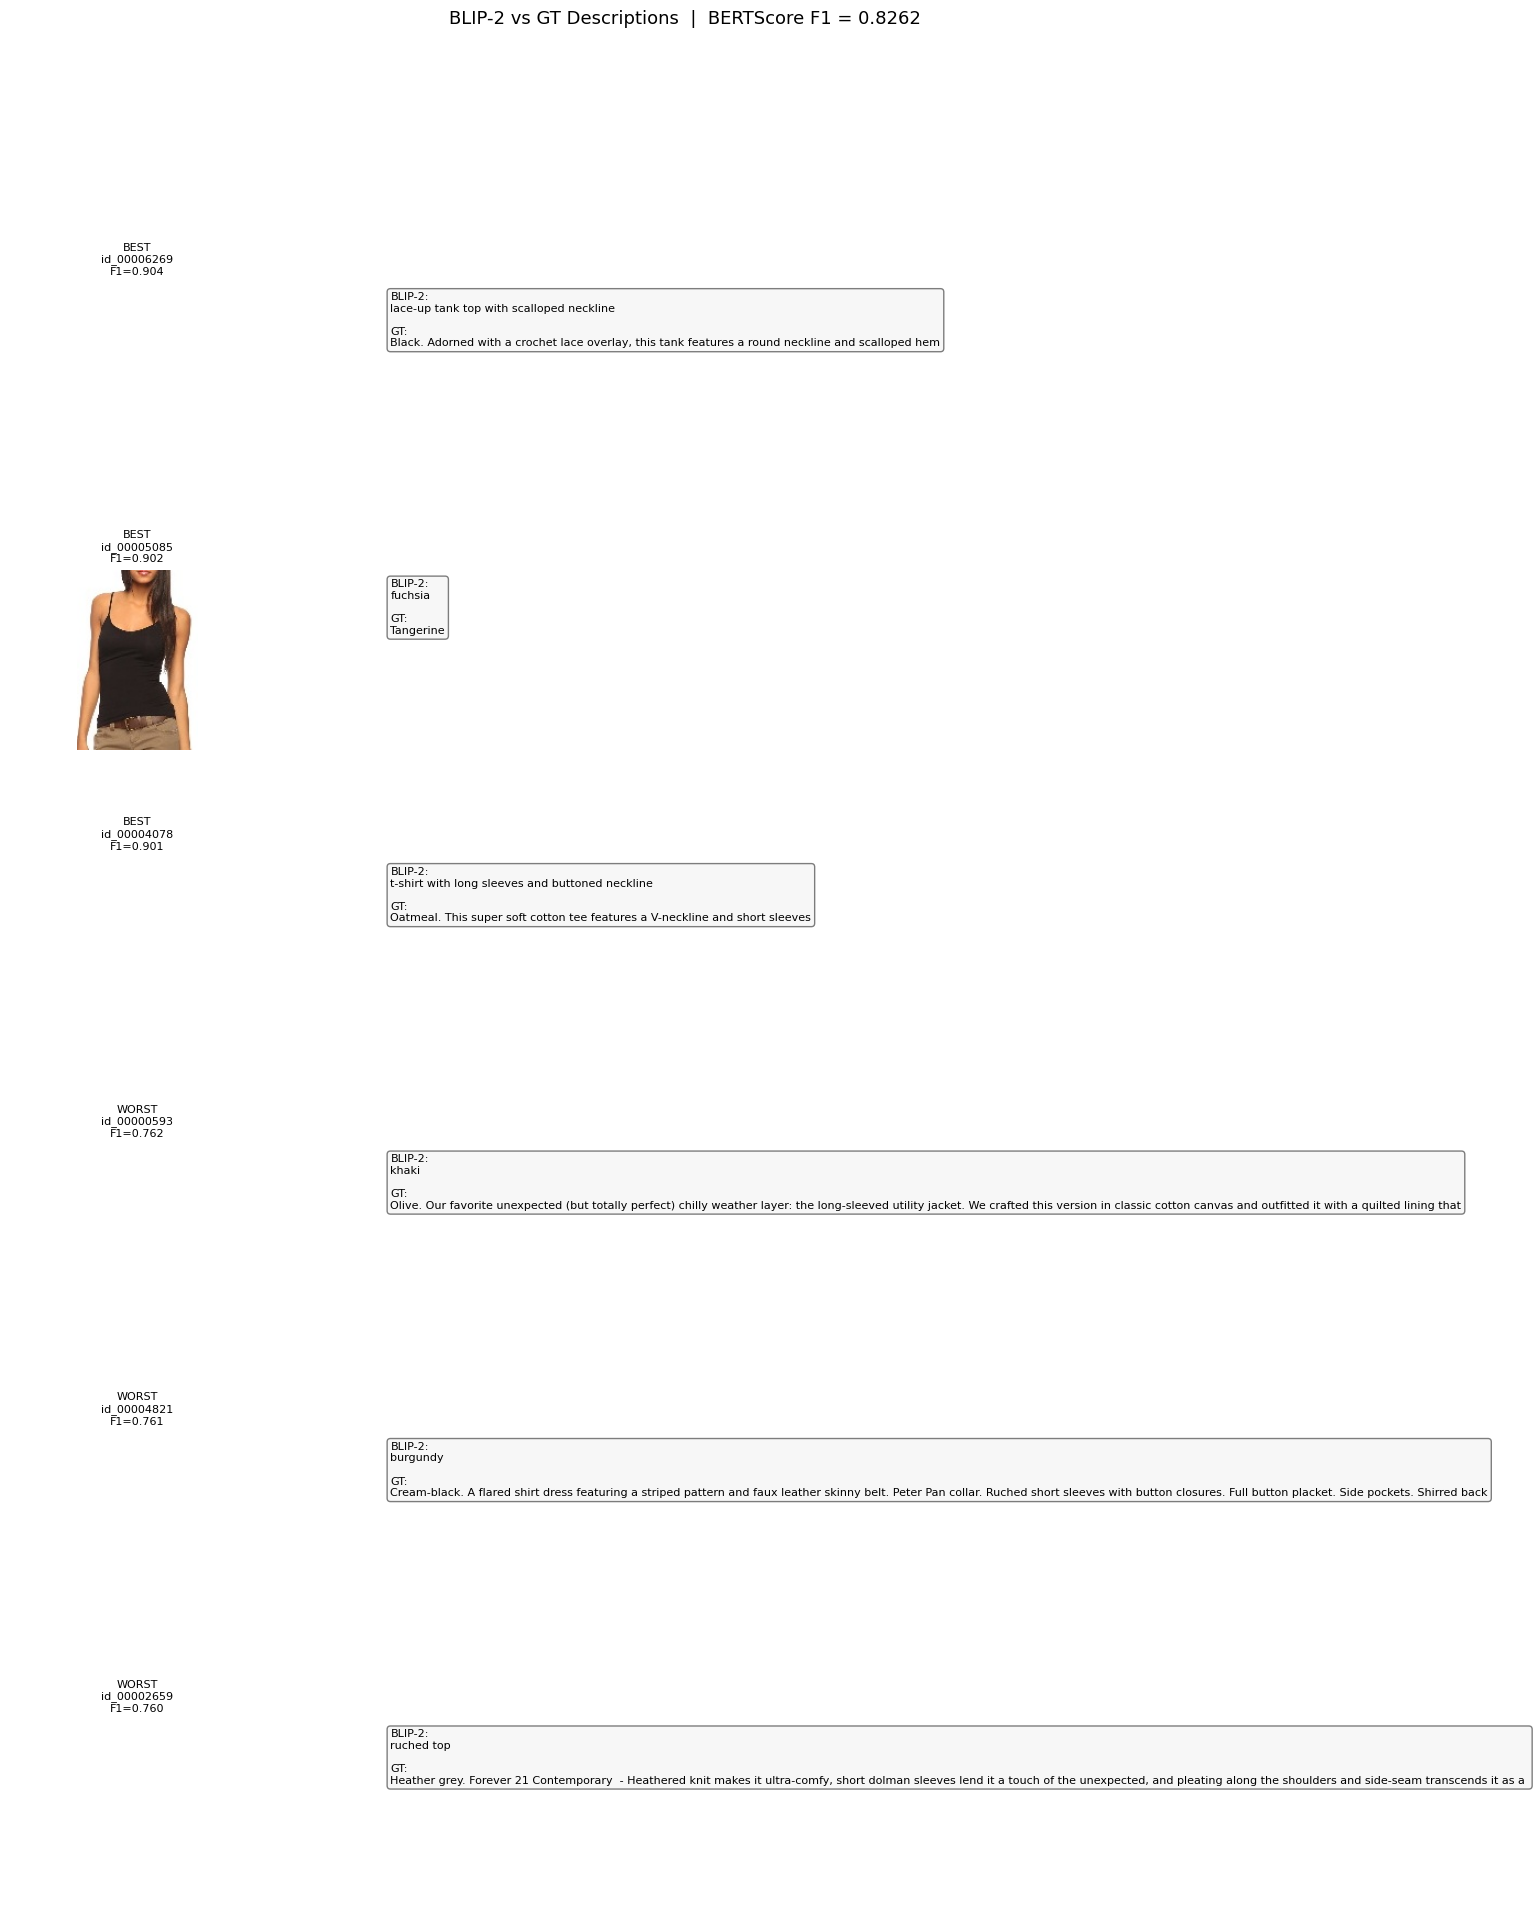

Saved → blip2_eval_sample.png


In [9]:
# Sort by F1 to show best and worst examples
scored_items = sorted(
    eval_results['per_item'],
    key=lambda x: x['f1'],
    reverse=True
)

# Pick top 3 (best) and bottom 3 (worst)
showcase = scored_items[:3] + scored_items[-3:]
labels   = ['BEST'] * 3 + ['WORST'] * 3

fig = plt.figure(figsize=(18, len(showcase) * 3.5))
gs  = gridspec.GridSpec(len(showcase), 2, width_ratios=[1, 4], hspace=0.6)

for row_idx, (item, label) in enumerate(zip(showcase, labels)):
    item_id = item['item_id']

    # Find the front image for this item in the crop root
    matches = list(CROP_ROOT.rglob(f'{item_id}/02_1_front.jpg'))
    ax_img  = fig.add_subplot(gs[row_idx, 0])
    if matches:
        ax_img.imshow(Image.open(matches[0]).convert('RGB'))
    ax_img.axis('off')
    ax_img.set_title(f'{label}\n{item_id}\nF1={item["f1"]:.3f}', fontsize=8)

    ax_txt = fig.add_subplot(gs[row_idx, 1])
    ax_txt.axis('off')
    text = (
        f"BLIP-2:\n{item['blip_caption']}\n\n"
        f"GT:\n{item['gt_caption'][:200]}"
    )
    ax_txt.text(0, 0.95, text, va='top', ha='left', fontsize=8,
                wrap=True, transform=ax_txt.transAxes,
                bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.5))

plt.suptitle(
    f'BLIP-2 vs GT Descriptions  |  BERTScore F1 = {mean_f1:.4f}',
    fontsize=13, y=1.01
)
plt.savefig(str(WORK_DIR / 'blip2_eval_sample.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → blip2_eval_sample.png')

## 9. F1 score distribution

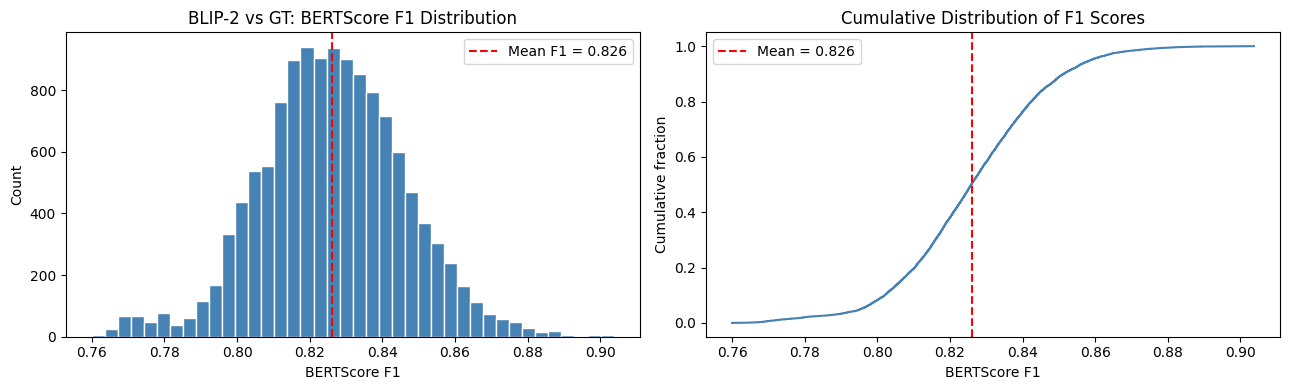

In [10]:
f1_scores = [item['f1'] for item in eval_results['per_item']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(f1_scores, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(mean_f1, color='red', linestyle='--', label=f'Mean F1 = {mean_f1:.3f}')
axes[0].set_xlabel('BERTScore F1')
axes[0].set_ylabel('Count')
axes[0].set_title('BLIP-2 vs GT: BERTScore F1 Distribution')
axes[0].legend()

# Cumulative distribution
import numpy as np
sorted_f1 = np.sort(f1_scores)
cdf = np.arange(1, len(sorted_f1)+1) / len(sorted_f1)
axes[1].plot(sorted_f1, cdf, color='steelblue')
axes[1].axvline(mean_f1, color='red', linestyle='--', label=f'Mean = {mean_f1:.3f}')
axes[1].set_xlabel('BERTScore F1')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Cumulative Distribution of F1 Scores')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(WORK_DIR / 'bertscore_distribution.png'), dpi=150)
plt.show()

## 10. Final summary

In [11]:
total_caps = len(captions_dict)

print('=' * 60)
print('  Step 2 Complete')
print('=' * 60)
print(f'  Total captions generated : {total_caps:,}')
print(f'  Captions file            : {CAPTIONS_OUT}')
print(f'  Eval file                : {EVAL_OUT}')
print()
print('  BERTScore (BLIP-2 vs GT):')
print(f'    Precision : {mean_p:.4f}')
print(f'    Recall    : {mean_r:.4f}')
print(f'    F1        : {mean_f1:.4f}')
print()
print('  captions.json format (input to Step 3):')
print('  {')
sample_key = list(captions_dict.keys())[0]
print(f'    "{sample_key}":')
print(f'      "{captions_dict[sample_key]}",')
print('    ...')
print('  }')
print()
print('  Next → Step 3: CLIP fine-tuning using images + BLIP-2 captions')
print('=' * 60)

  Step 2 Complete
  Total captions generated : 49,788
  Captions file            : /kaggle/working/captions.json
  Eval file                : /kaggle/working/blip2_vs_gt.json

  BERTScore (BLIP-2 vs GT):
    Precision : 0.8509
    Recall    : 0.8032
    F1        : 0.8262

  captions.json format (input to Step 3):
  {
    "MEN/Denim/id_00000080/01_1_front.jpg":
      "t-shirt black denim",
    ...
  }

  Next → Step 3: CLIP fine-tuning using images + BLIP-2 captions
